No reg λ=0


/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L2 λ=1e-06
L2 λ=1e-05
L2 λ=0.0001
L2 λ=0.001
L2 λ=0.01
L2 λ=0.1
L1 λ=1e-06
L1 λ=1e-05
L1 λ=0.0001
L1 λ=0.001
L1 λ=0.01
L1 λ=0.1
Elastic λ=1e-06
Elastic λ=1e-05
Elastic λ=0.0001
Elastic λ=0.001
Elastic λ=0.01
Elastic λ=0.1


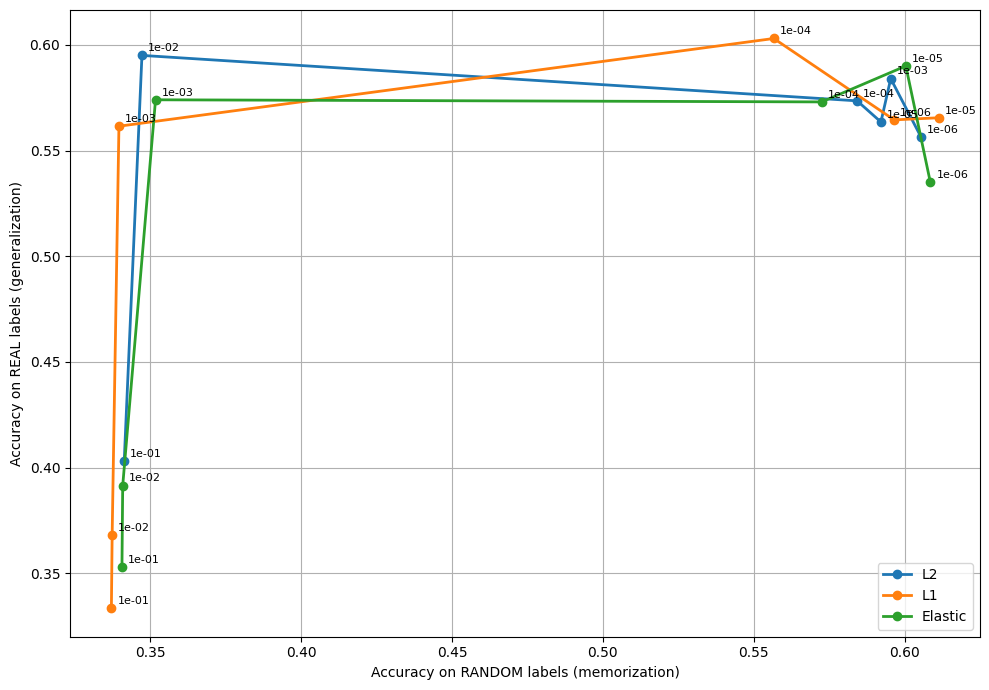

In [3]:
"""
Figure-10 style experiment (ORDERED version)

Key idea:
- Train same architecture under different regularization strengths
- Measure:
    x-axis = memorization (accuracy on RANDOM labels)
    y-axis = generalization (accuracy on REAL labels)

IMPORTANT IMPROVEMENT:
- Curves are sorted by memorization BEFORE plotting
"""

import numpy as np
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# Reproducibility
# ============================================================

np.random.seed(12345)
tf.random.set_seed(12345)

# ============================================================
# Data generation
# ============================================================

def jump(d1, d2, s1, s2):
    return [
        int(np.random.normal(d1, s1)),
        int(np.random.normal(d2, s2))
    ]

def pattern(i, z1, z2, a1, a2):
    return [
        int(a1 * np.sin(np.pi * i / z1)),
        int(a2 * np.sin(np.pi * i / z2))
    ]

def generate_dataset(N, L, d, A1, A2, sigma, bias, n_class=3):

    x = np.zeros((N, L, 2), dtype=np.float32)
    y = np.zeros(N, dtype=np.int32)

    for i in range(N):

        if i > 0:
            j0, j1 = jump(bias, bias, sigma, sigma)
            x[i, 0, 0] = x[i-1, -1, 0] + j0
            x[i, 0, 1] = x[i-1, -1, 1] + j1

        for j in range(1, L):
            j0, j1 = jump(bias, bias, sigma, sigma)
            x[i, j, 0] = x[i, j-1, 0] + j0
            x[i, j, 1] = x[i, j-1, 1] + j1

        y[i] = i % n_class

        if y[i] > 0:
            j01, j02 = np.random.randint(0, L - d - 1, 2)
            sign = 3 - 2 * y[i]

            for j in range(d):
                p1, p2 = pattern(j, d, d, A1, A2)
                x[i, j01 + j, 0] += sign * p1
                x[i, j02 + j, 1] += sign * p2

    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)

    y_oh = np.eye(n_class)[y].astype(np.float32)

    return x, y_oh

def randomize_labels(y, n_class=3):
    rnd = np.random.randint(0, n_class, size=len(y))
    return np.eye(n_class)[rnd].astype(np.float32)

# ============================================================
# Model
# ============================================================

def build_model(L, l, r, n_class=3):

    reg = None

    if l != 0:
        if r == 2:
            reg = keras.regularizers.l2(l)
        elif r == 1:
            reg = keras.regularizers.l1(l)
        else:
            reg = keras.regularizers.L1L2(l1=l, l2=l)

    model = Sequential([
        Conv1D(5, 11, activation='relu', padding='same',
               input_shape=(L, 2), kernel_regularizer=reg),
        MaxPooling1D(2),

        Conv1D(10, 5, activation='relu', kernel_regularizer=reg),
        MaxPooling1D(2),

        Flatten(),
        Dense(32, activation='relu', kernel_regularizer=reg),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================================
# Parameters
# ============================================================

N, L, d = 10000, 60, 11
sigma, bias = 20, 5
n_class = 3

SNR = 3
A1 = (2 * (np.pi + 4) * d * SNR / np.pi**3) ** 0.5 * sigma
A2 = A1

x, y_true = generate_dataset(N, L, d, A1, A2, sigma, bias, n_class)

N_train = int(0.8 * N)

x_train, x_val = x[:N_train], x[N_train:]
y_train_true, y_val = y_true[:N_train], y_true[N_train:]

y_train_random = randomize_labels(y_train_true, n_class)

# ============================================================
# Experiment configs
# ============================================================

CONFIGS = [
    ("No reg", 0, 0),

    ("L2", 1e-6, 2),
#    ("L2", 0.5e-6, 2),
    ("L2", 1e-5, 2),
#    ("L2", 0.5e-5, 2),
    ("L2", 1e-4, 2),
#    ("L2", 0.5e-4, 2),
    ("L2", 1e-3, 2),
#    ("L2", 0.5e-3, 2),
    ("L2", 1e-2, 2),
#    ("L2", 0.5e-2, 2),
    ("L2", 1e-1, 2),

    ("L1", 1e-6, 1),
#    ("L1", 0.5e-6, 1),
    ("L1", 1e-5, 1),
#    ("L1", 0.5e-5, 1),
    ("L1", 1e-4, 1),
#    ("L1", 0.5e-4, 1),
    ("L1", 1e-3, 1),
#    ("L1", 0.5e-3, 1),
    ("L1", 1e-2, 1),
#    ("L1", 0.5e-2, 1),
    ("L1", 1e-1, 1),

    ("Elastic", 1e-6, 0),
#    ("Elastic", 0.5e-6, 0),
    ("Elastic", 1e-5, 0),
#    ("Elastic", 0.5e-5, 0),
    ("Elastic", 1e-4, 0),
#    ("Elastic", 0.5e-4, 0),
    ("Elastic", 1e-3, 0),
#    ("Elastic", 0.5e-3, 0),
    ("Elastic", 1e-2, 0),
#    ("Elastic", 0.5e-2, 0),
    ("Elastic", 1e-1, 0),
]

# ============================================================
# Run experiment
# ============================================================

results = []

for name, l, r in CONFIGS:

    print(f"{name} λ={l}")

    model_real = build_model(L, l, r, n_class)
    model_noise = build_model(L, l, r, n_class)

    # -------------------------
    # TRAIN ON REAL LABELS
    # -------------------------
    model_real.fit(
        x_train, y_train_true,
        validation_data=(x_val, y_val),
        epochs=200,
        batch_size=200,
        verbose=False,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=20,
                restore_best_weights=True
            )
        ]
    )

    real_acc = max(model_real.history.history['val_accuracy'])

    # -------------------------
    # TRAIN ON RANDOM LABELS
    # -------------------------
    model_noise.fit(
        x_train, y_train_random,
        epochs=200,
        batch_size=200,
        verbose=False,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='accuracy',
                patience=20,
                restore_best_weights=True
            )
        ]
    )

    noise_acc = max(model_noise.history.history['accuracy'])

    results.append({
        "reg": name,
        "lambda": l,
        "noise_acc": noise_acc,
        "real_acc": real_acc
    })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

# ============================================================
# PLOT (ORDERED)
# ============================================================

plt.figure(figsize=(10, 7))

for reg in ["L2", "L1", "Elastic"]:

    sub = df[df["reg"] == reg].copy()

    # IMPORTANT: order by memorization (x-axis)
    sub = sub.sort_values("noise_acc")

    plt.plot(
        sub["noise_acc"],
        sub["real_acc"],
        marker="o",
        linewidth=2,
        label=reg
    )

    # annotate lambda values
    for _, row in sub.iterrows():
        plt.text(
            row["noise_acc"] + 0.002,
            row["real_acc"] + 0.002,
            f"{row['lambda']:.0e}",
            fontsize=8
        )

# No regularization separately
no_reg = df[df["reg"] == "No reg"]

'''
plt.scatter(
    no_reg["noise_acc"],
    no_reg["real_acc"],
    c="black",
    s=180,
    marker="X",
    label="No reg"
)
'''
plt.xlabel("Accuracy on RANDOM labels (memorization)")
plt.ylabel("Accuracy on REAL labels (generalization)")
#plt.title("Figure 10 style (ordered by memorization)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.tight_layout()

# SAVE FIGURE
plt.savefig(
    "memorization_vs_generalization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()